In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 
import plotly.graph_objects as go
from scipy.interpolate import griddata
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.ndimage import gaussian_filter
from scipy.interpolate import SmoothBivariateSpline
from scipy.signal import savgol_filter
from scipy.ndimage import median_filter
from skimage.restoration import denoise_tv_chambolle
from scipy.ndimage import convolve
import copy
from matplotlib.colors import LinearSegmentedColormap

### Importation of PMF Data

#### Data Implementation
X axis will be dihedrals, Y axis is setted as distances and Z axis is energy

In [2]:
pmf_data1 = np.loadtxt('merged_replicas_boltzmann_holo_p.pmf')
pmf_data2 = np.loadtxt('merged_replicas_boltzmann_apo_p.pmf')
pmf_data3 = np.loadtxt('merged_replicas_boltzmann_holo_l.pmf')
pmf_data4 = np.loadtxt('merged_replicas_boltzmann_apo_l.pmf')

In [3]:
dihedrals = pmf_data1[:,0]
distances = pmf_data1[:,1]

In [4]:
#dihedrals

In [5]:
#distances

In [6]:
def normalize(pmf_data):
    dihedrals = pmf_data[:, 0]
    distances = pmf_data[:, 1]
    energy = pmf_data[:, 2]

    # Set initial value for suitable_lines to None for checking if a match is found
    suitable_lines = None

    # Target values
    target_distance = 33.8
    target_dihedral = 98

    # Tolerances
    distance_tolerance = 0.75  # Covers from 33.25 to 34.75
    dihedral_tolerance = 7     # Covers from 95 to 105

    # Iterate through the data to find a match within the specified tolerance
    for i in range(len(energy)):
        if (abs(distances[i] - target_distance) <= distance_tolerance) and (abs(dihedrals[i] - target_dihedral) <= dihedral_tolerance):
            suitable_lines = energy[i]
            print(f"Suitable energy found at index {i}: {suitable_lines}")
            break

    # If no suitable energy is found, use a default value or handle accordingly
    if suitable_lines is None:
        print("No suitable match found. Using default processing.")
        suitable_lines = np.mean(energy)  # Could use zero or any other baseline as needed

    # Normalize the energy array by subtracting the found suitable_lines
    normalized_energy = energy - suitable_lines
    return normalized_energy

# Use this function by passing the actual data array
# energy_normalized = normalize(pmf_data)


In [7]:
energy1 = normalize(pmf_data1)

Suitable energy found at index 744: 13.5340895533926


In [8]:
#energy1

In [9]:

# Function adjusted to process PMF data similar to your original approach
def process_pmf_data_adjusted(pmf_data):
    dihedrals = pmf_data[:, 0]
    distances = pmf_data[:, 1]
    energy = normalize(pmf_data)

    X = dihedrals  # Negate dihedrals for your specific need
    Y = distances
    Z_energy = energy

    # Dynamically determine grid dimensions based on the unique counts
    grid_x_len = len(set(X))
    grid_y_len = len(set(Y))

    # Ensure the total length of the dataset is divisible by both dimensions
    assert len(X) % grid_x_len == 0, "Total length must be divisible by grid_x_len"
    assert len(Y) % grid_y_len == 0, "Total length must be divisible by grid_y_len"

    # Reshape arrays directly to 2D forms with calculated grid dimensions
    X_2D = X.reshape(-1, grid_y_len)
    Y_2D = Y.reshape(grid_x_len, -1)
    Z_energy_2D = Z_energy.reshape(grid_x_len, grid_y_len)

    return X_2D, Y_2D, Z_energy_2D

In [10]:
# Assuming pmf_data1, pmf_data2, pmf_data3, pmf_data4 are defined and loaded
X_2D1, Y_2D1, Z_energy_2D1 = process_pmf_data_adjusted(pmf_data1)
X_2D2, Y_2D2, Z_energy_2D2 = process_pmf_data_adjusted(pmf_data2)
X_2D3, Y_2D3, Z_energy_2D3 = process_pmf_data_adjusted(pmf_data3)
X_2D4, Y_2D4, Z_energy_2D4 = process_pmf_data_adjusted(pmf_data4)

Suitable energy found at index 744: 13.5340895533926
Suitable energy found at index 744: 5.75534539497465
Suitable energy found at index 744: 1.64810608203189
Suitable energy found at index 744: 5.50697530903645


In [11]:
energy_datasets = [Z_energy_2D1, Z_energy_2D2, Z_energy_2D3, Z_energy_2D4]

# Iterate through each dataset and calculate max and min energies
for i, dataset in enumerate(energy_datasets, start=1):
    max_energy = np.max(dataset)
    min_energy = np.min(dataset)
    print(f"PMF Data {i}: Max Energy = {max_energy}, Min Energy = {min_energy}")

PMF Data 1: Max Energy = 8.3383352342877, Min Energy = -13.5340895533926
PMF Data 2: Max Energy = 5.644137376603351, Min Energy = -5.75534539497465
PMF Data 3: Max Energy = 9.30588618485681, Min Energy = -1.64810608203189
PMF Data 4: Max Energy = 4.9935793407455495, Min Energy = -5.50697530903645


In [12]:
def load_data(file_name):
    """Load NMR data from a given file name."""
    return np.loadtxt(file_name)


In [13]:
def prepare_data(data):
    """Extract and prepare X, Y, and Z data from loaded NMR data."""
    dihedrals = data[:, 0]
    distances = data[:, 1]
    energy = data[:, 2]
    return dihedrals, distances, energy

/var/folders/fx/s7zv3zv93zqg5n5t76zy46700000gn/T/ipykernel_52432/2959029433.py:189: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


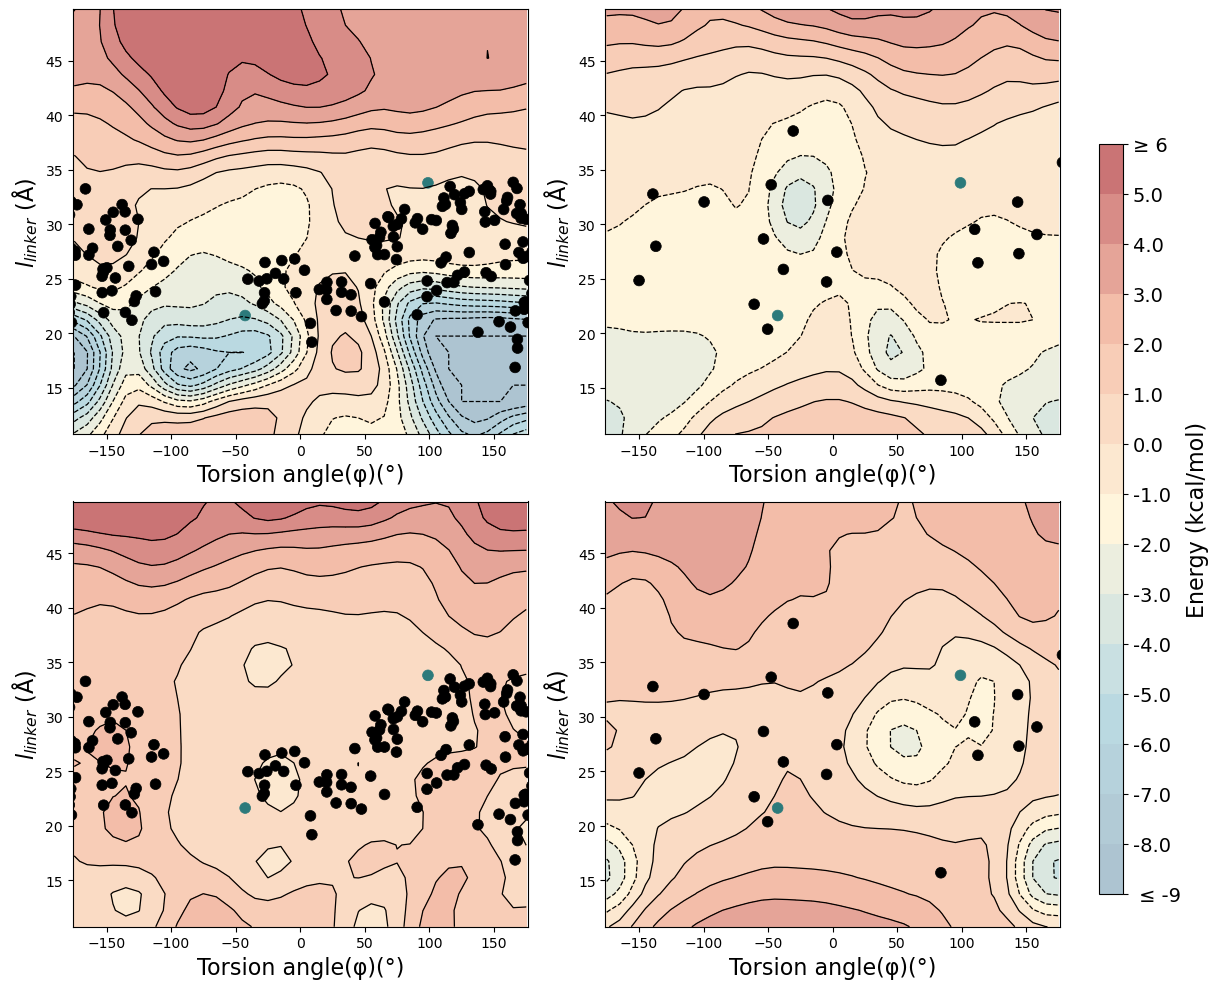

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import MultipleLocator, AutoMinorLocator
from scipy.ndimage import convolve

def smooth_energy(Z_energy_2D, kernel_type='7x7'):
    """
    Apply smoothing using a Gaussian-like kernel to the Z_energy_2D data.
    """
    kernel_dict = {
        '3x3': np.array([[1, 2, 1],
                         [2, 4, 2],
                         [1, 2, 1]]) / 16,

        '5x5': np.array([[1, 4, 6, 4, 1],
                         [4, 16, 24, 16, 4],
                         [6, 24, 36, 24, 6],
                         [4, 16, 24, 16, 4],
                         [1, 4, 6, 4, 1]]) / 256,

        '7x7': np.array([[1, 6, 15, 20, 15, 6, 1],
                         [6, 36, 90, 120, 90, 36, 6],
                         [15, 90, 225, 300, 225, 90, 15],
                         [20, 120, 300, 400, 300, 120, 20],
                         [15, 90, 225, 300, 225, 90, 15],
                         [6, 36, 90, 120, 90, 36, 6],
                         [1, 6, 15, 20, 15, 6, 1]]) / 4096
    }

    if kernel_type not in kernel_dict:
        raise ValueError("Invalid kernel type. Choose from '3x3', '5x5', or '7x7'.")

    kernel = kernel_dict[kernel_type]
    return convolve(Z_energy_2D, kernel)


def create_custom_colormap():
    """
    Create a custom colormap.
    """
    colors = ['#7498af', '#8fc3d1', '#fff0c7', '#f19c79', '#9e040c']
    return LinearSegmentedColormap.from_list("custom_pmf", colors, N=256)


def plot_smoothed_energy_contour(ax, X_2D, Y_2D, Z_energy_2D, kernel_type='7x7'):
    """
    Plot the smoothed energy contour for given 2D energy data.
    """
    Z_energy_2D_smooth_g = smooth_energy(Z_energy_2D, kernel_type=kernel_type)

    # Clip values for contour visualization
    Z_energy_2D_smooth_g = np.clip(Z_energy_2D_smooth_g, -9, 6)

    cmap = create_custom_colormap()
    levels = np.linspace(-9, 6, 16)

    contourf = ax.contourf(
        X_2D, Y_2D, Z_energy_2D_smooth_g,
        levels=levels, cmap=cmap, alpha=0.6
    )
    ax.contour(
        X_2D, Y_2D, Z_energy_2D_smooth_g,
        levels=levels, colors='k', linewidths=0.9
    )

    ax.set_xlabel('Torsion angle(φ)(°)', fontsize=16)
    ax.set_ylabel(r'$l_{\mathit{linker}}$ (Å)', fontsize=16)

    return contourf


def load_data(file_name):
    """Load NMR data from a given file name."""
    return np.loadtxt(file_name)


def prepare_data(data):
    """Extract and prepare X, Y, and Z data from loaded NMR data."""
    dihedrals = data[:, 0]
    distances = data[:, 1]
    energy = data[:, 2]
    return dihedrals, distances, energy


def value_to_color(z):
    if z == 10.0:
        return '#4B6CB7'
    if z == 11.0:
        return '#2C7A7B'
    if z == 12.0:
        return '#8E4585'
    if z == 5.0:
        return '#C45A87'
    if z == 6.0:
        return '#2C7A7B'
    return 'black'


# -----------------------------
# Figure and energy landscapes
# -----------------------------
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))

data_sets = [
    (X_2D1, Y_2D1, Z_energy_2D1),  # top-left
    (X_2D2, Y_2D2, Z_energy_2D2),  # top-right
    (X_2D3, Y_2D3, Z_energy_2D3),  # bottom-left
    (X_2D4, Y_2D4, Z_energy_2D4)   # bottom-right
]

# -----------------------------
# Load scatter data
# -----------------------------
file_name_1 = 'holo.txt'   # holo
file_name_2 = 'apo.txt'                 # apo

data1 = load_data(file_name_1)
data2 = load_data(file_name_2)

X1, Y1, Z1 = prepare_data(data1)   # holo
X2, Y2, Z2 = prepare_data(data2)   # apo

# Precompute colors
colors1 = [value_to_color(z) for z in Z1]
colors2 = [value_to_color(z) for z in Z2]

# Marker sizes
sizes1 = [80 if value_to_color(z) not in ['#2C7A7B', 'black'] else 60 for z in Z1]
sizes2 = [80 if value_to_color(z) not in ['#2C7A7B', 'black'] else 60 for z in Z2]

# Black/teal-only versions
bw_colors1 = ['#2C7A7B' if z == 6 else 'black' for z in Z1]
bw_colors2 = ['#2C7A7B' if z == 6 else 'black' for z in Z2]

# Axis limits
dihedral_range = np.linspace(-176, 176)
distance_range = np.linspace(10.75, 49.75)

# -----------------------------
# Plot panels
# Left column  = holo
# Right column = apo
# -----------------------------
contours = []

for i, (ax, (X, Y, Z)) in enumerate(zip(axes.flat, data_sets)):
    contours.append(plot_smoothed_energy_contour(ax, X, Y, Z))

    col = i % 2  # 0 = left, 1 = right

    if col == 0:
        # LEFT COLUMN = HOLO
        if i == 0:
            # (1,1) top-left -> colored holo
            ax.scatter(X1, Y1, c=colors1, s=sizes1, alpha=1.0, linewidth=0.5)
        else:
            # (2,1) bottom-left -> black/teal holo
            ax.scatter(X1, Y1, c=bw_colors1, s=60, alpha=1.0, linewidth=0.5)
    else:
        # RIGHT COLUMN = APO
        if i == 1:
            # (1,2) top-right -> colored apo
            ax.scatter(X2, Y2, c=colors2, s=sizes2, alpha=1.0, linewidth=0.5)
        else:
            # (2,2) bottom-right -> black/teal apo
            ax.scatter(X2, Y2, c=bw_colors2, s=60, alpha=1.0, linewidth=0.5)

    ax.set_xlim(dihedral_range.min(), dihedral_range.max())
    ax.set_ylim(distance_range.min(), distance_range.max())


# -----------------------------
# Colorbar
# -----------------------------
cbar_ax = fig.add_axes([0.92, 0.1, 0.02, 0.75])  # [left, bottom, width, height]
cbar = fig.colorbar(contours[1], cax=cbar_ax)
cbar.set_label('Energy (kcal/mol)', fontsize=16)
cbar.ax.tick_params(labelsize=14)

cbar_ticks = np.linspace(-9, 6, 16)
cbar.set_ticks(cbar_ticks)

cbar_labels = [f'{tick:.1f}' for tick in cbar_ticks]
cbar_labels[0] = ' ≤ -9'
cbar_labels[-1] = '≥ 6'
cbar.set_ticklabels(cbar_labels)

plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.savefig('overlayed_plot_meta.png', format='png', dpi=1200)
plt.show()

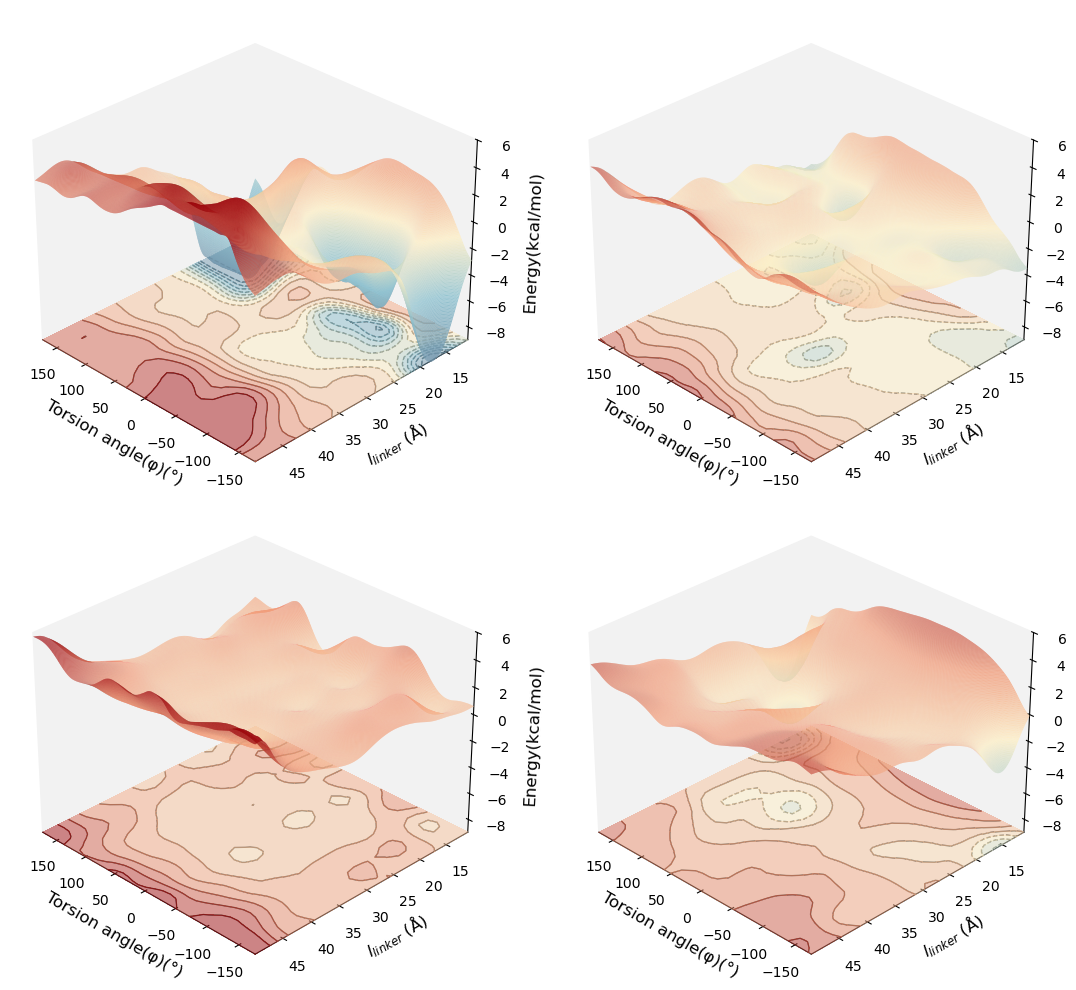

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import convolve
from matplotlib.colors import LinearSegmentedColormap
from scipy.interpolate import griddata
from matplotlib.colors import Normalize

def interpolate_grid(X, Y, Z, resolution=150):
    """
    Interpolates the given grid to a higher resolution to avoid square artifacts.
    """
    x_new = np.linspace(X.min(), X.max(), resolution)
    y_new = np.linspace(Y.min(), Y.max(), resolution)
    X_new, Y_new = np.meshgrid(x_new, y_new)
    Z_new = griddata((X.flatten(), Y.flatten()), Z.flatten(),
                     (X_new, Y_new), method='cubic')
    return X_new, Y_new, Z_new

def plot_smoothed_energy_3D_with_contour(ax, X_2D, Y_2D, Z_energy_2D, kernel_type='7x7'):
    """
    Plot the smoothed energy as a 3D surface with a fixed 2D contour projection at z = -9.
    """
    # ✅ Apply smoothing and clip values correctly
    Z_energy_2D_smooth_g = smooth_energy(Z_energy_2D, kernel_type=kernel_type)
    Z_energy_2D_smooth_g = np.clip(Z_energy_2D_smooth_g, -9, 6)  # Ensure values are in range [-9, 6]

    # ✅ Use the correct colormap
    cmap2 = create_custom_colormap()
    
    # ✅ Interpolate grid for a smoother surface
    X_2D_interp, Y_2D_interp, Z_energy_2D_interp = interpolate_grid(
        X_2D, Y_2D, Z_energy_2D_smooth_g, resolution=400
    )

    # ✅ Interpolate `masked_Z` for contour plot
    masked_Z_interp = np.ma.masked_where(Z_energy_2D_interp > 0, Z_energy_2D_interp)

    # ✅ 3D Surface Plot with the correct colormap and fine resolution
    surf = ax.plot_surface(
        X_2D_interp, Y_2D_interp, Z_energy_2D_interp,
        cmap=cmap2, edgecolor='none',
        vmin=-9, vmax=6, rstride=1, cstride=1
    )

    # ✅ Set contour projection at Z = -9 (fixed)
    z_contour = -9
    levels = np.linspace(-9, 6, 16)  # Define contour levels with correct range

    # ✅ 2D Contour Fill (colored contours at z = -9)
    contourf = ax.contourf(
        X_2D, Y_2D, Z_energy_2D_smooth_g,
        zdir='z', offset=z_contour,
        levels=levels, cmap=cmap2, alpha=0.5
    )
    
    # ✅ 2D Contour Lines (black contour edges)
    ax.contour(
        X_2D, Y_2D, Z_energy_2D_smooth_g,
        zdir='z', offset=z_contour,
        levels=levels, colors='k', linewidths=0.9
    )

    # Labels and view adjustments
    ax.set_xlabel('Torsion angle(φ)(°)', fontsize=12)
    ax.set_ylabel(r'$l_{\mathit{linker}}$ (Å)', fontsize=12)
    ax.set_zlabel('Energy(kcal/mol)', fontsize=12)

    ax.set_zlim(-9, 6)                      # keep your original z-range
    ax.view_init(elev=30, azim=135)
    ax.grid(False)

    # -------- FIXES --------
    # outside figure background white
    ax.set_facecolor('white')

    # keep light grey panes (box appearance), but slightly lighter than default
    ax.xaxis.set_pane_color((0.95, 0.95, 0.95, 1.0))
    ax.yaxis.set_pane_color((0.95, 0.95, 0.95, 1.0))
    ax.zaxis.set_pane_color((0.95, 0.95, 0.95, 1.0))

    # remove x/y padding so contour plane touches axes (no gap)
    ax.set_xlim(X_2D.min(), X_2D.max())
    ax.set_ylim(Y_2D.min(), Y_2D.max())
    # -----------------------

    return surf, contourf

# Example usage
fig = plt.figure(figsize=(12, 10))

data_sets = [
    (X_2D1, Y_2D1, Z_energy_2D1),
    (X_2D2, Y_2D2, Z_energy_2D2),
    (X_2D3, Y_2D3, Z_energy_2D3),
    (X_2D4, Y_2D4, Z_energy_2D4)
]

for i, (X, Y, Z) in enumerate(data_sets):
    ax = fig.add_subplot(2, 2, i + 1, projection='3d')  # 3D subplot
    surf, contourf = plot_smoothed_energy_3D_with_contour(ax, X, Y, Z)

plt.tight_layout()
plt.savefig('pmf_3D_plots_with_fixed_contour.png', format='png', dpi=300)
plt.show()
